In [ ]:
from typing import List, TypedDict
from langgraph.graph import StateGraph, START, END
import random

In [2]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [9]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node says hi to the person"""
    state['name'] = f'Hi there, {state['name']}'
    state['counter'] = 0

    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""
    state['number'].append(random.randint(0,10))
    state['counter'] += 1

    return state

def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state['counter'] < 5:
        print("Entering loop", state['counter'])
        return 'loop'
    else:
        return 'exit'

In [10]:
graph = StateGraph(AgentState)

graph.add_node('greeting', greeting_node)
graph.add_node('random', random_node)

graph.add_edge(START, 'greeting')

graph.add_edge('greeting', 'random')

graph.add_conditional_edges(
    'random',
    should_continue,
    {
        'loop': 'random',
        'exit': END
    }
)

app = graph.compile()

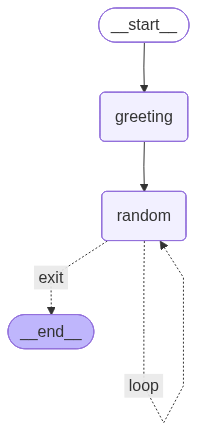

In [11]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
app.invoke({'name': 'Le', 'number': [], 'counter': -20})

Entering loop 1
Entering loop 2
Entering loop 3
Entering loop 4


{'name': 'Hi there, Le', 'number': [0, 4, 2, 3, 4], 'counter': 5}